In [ ]:
!pip install category_encoders
!pip uninstall -y tensorflow && pip install tensorflow-cpu
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.4 MB/s eta 0:00:00
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.0/259.0 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.4 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
file_name = '/content/drive/MyDrive/Colab Notebooks/fake_job_postings.csv'
df = pd.read_csv(file_name, encoding='utf-8')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/fake_job_postings.csv'

#EDA & Visualization

In [ ]:
df.info()

In [ ]:
df.describe(include='all')

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
count,17880.000000,17880,17534,6333,2868,14572,17879,15184,10668,17880.000000,17880.000000,17880.000000,14409,10830,9775,12977,11425,17880.000000
unique,NaN,11231,3105,1337,874,1709,14801,11967,6204,NaN,NaN,NaN,5,7,13,131,37,NaN
top,NaN,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,NaN,NaN,NaN,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,NaN
freq,NaN,311,718,551,142,726,379,410,726,NaN,NaN,NaN,11620,3809,5145,1734,1749,NaN
mean,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042897,0.795302,0.491723,NaN,NaN,NaN,NaN,NaN,0.048434
std,5161.655742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.202631,0.403492,0.499945,NaN,NaN,NaN,NaN,NaN,0.214688
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4470.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,13410.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000


In [ ]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

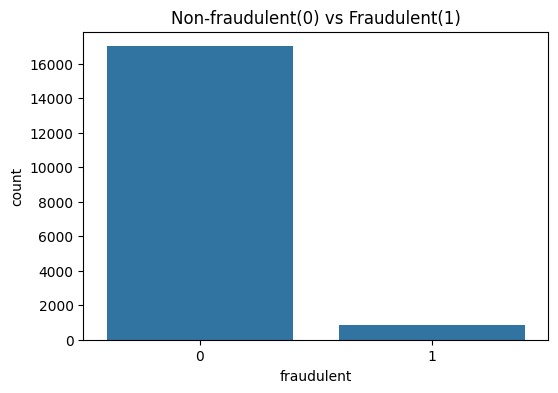

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='fraudulent', data=df)
plt.title('Non-fraudulent(0) vs Fraudulent(1)')
plt.show()

In [ ]:
df['fraudulent'].value_counts(normalize=True) * 100

,proportion
fraudulent,
0,95.1566
1,4.8434


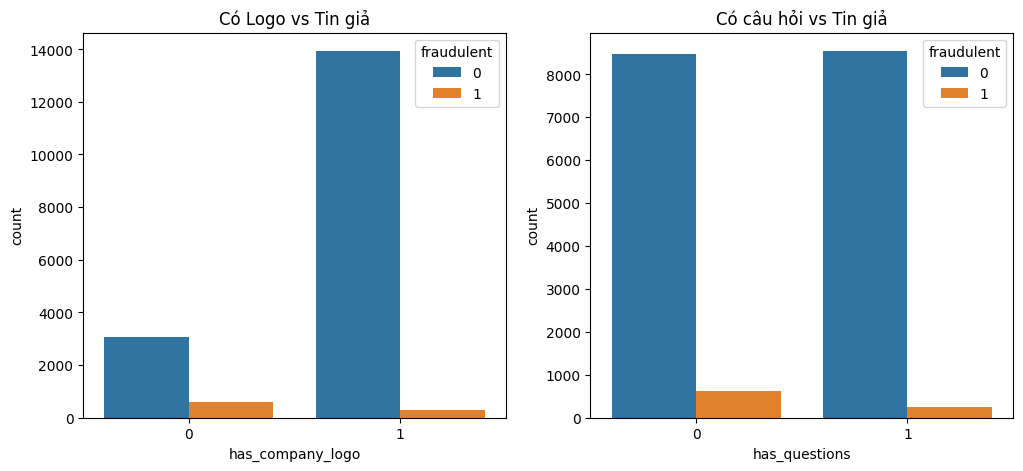

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='has_company_logo', hue='fraudulent', data=df, ax=ax1)
ax1.set_title('Có Logo vs Tin giả')

sns.countplot(x='has_questions', hue='fraudulent', data=df, ax=ax2)
ax2.set_title('Có câu hỏi vs Tin giả')

plt.show()

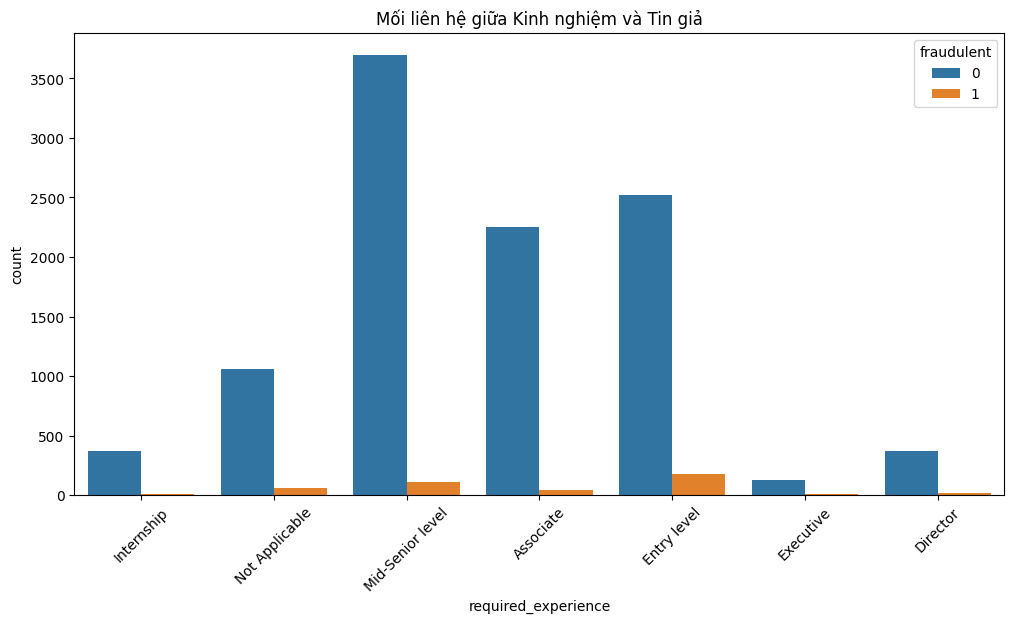

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='required_experience', hue='fraudulent', data=df)
plt.title('Mối liên hệ giữa Kinh nghiệm và Tin giả')
plt.xticks(rotation=45)
plt.show()

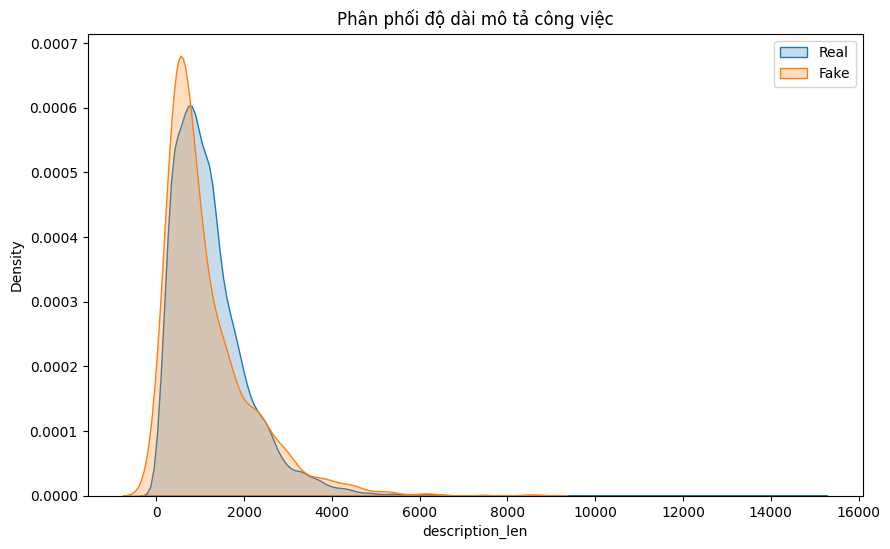

In [ ]:
df['description_len'] = df['description'].str.len()

plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['fraudulent']==0]['description_len'], label='Real', fill=True)
sns.kdeplot(df[df['fraudulent']==1]['description_len'], label='Fake', fill=True)
plt.title('Phân phối độ dài mô tả công việc')
plt.legend()
plt.show()

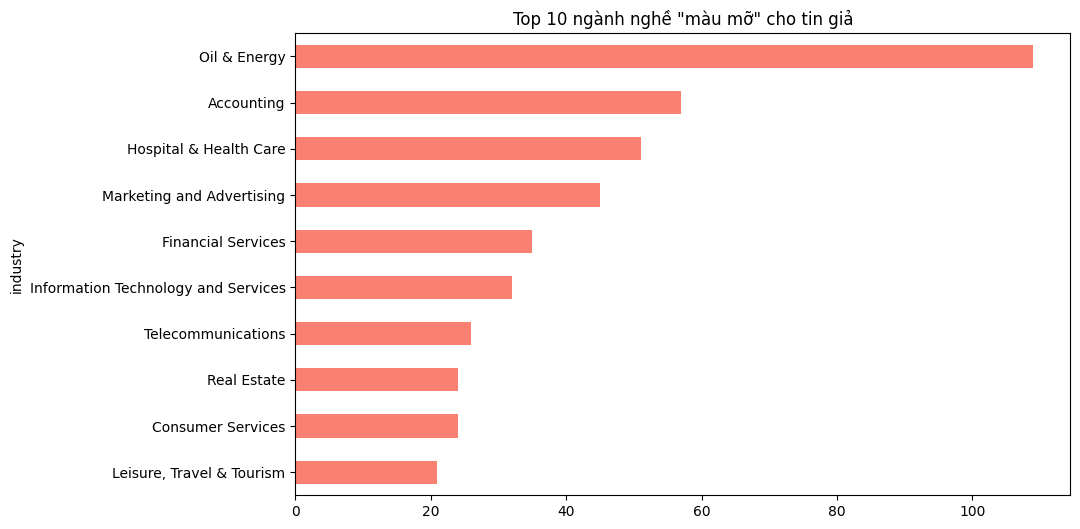

In [ ]:
top_fake_industries = df[df['fraudulent']==1]['industry'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_fake_industries.plot(kind='barh', color='salmon')
plt.title('Top 10 ngành nghề "màu mỡ" cho tin giả')
plt.gca().invert_yaxis()
plt.show()

#Features Preprocessing

In [ ]:
df=df.fillna('')

In [ ]:
df.isnull().sum()

,0
job_id,0
title,0
location,0
department,0
salary_range,0
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0


In [ ]:
import torch
import gc
from transformers import DistilBertTokenizer, DistilBertModel
from torch.cuda.amp import autocast

# 1. Thiết lập thiết bị GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang chạy trên: {device}")

# 2. Load DistilBERT
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertModel.from_pretrained(model_name).to(device)

# 3. Kết hợp văn bản
text_features = ['title', 'company_profile', 'description', 'requirements', 'benefits']
df['combined_text'] = df[text_features].agg(' '.join, axis=1)
texts = df['combined_text']

# 4. Tokenize dữ liệu
tokenized_texts = tokenizer(
    texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors='pt',
    add_special_tokens=True
)

# 5. Cấu hình Batch Processing
batch_size = 64
embeddings = []

# 6. Trích xuất Embeddings với tư duy Green AI
model.eval() # Chuyển sang chế độ evaluation
with torch.no_grad():
    for i in range(0, len(texts), batch_size):
        # Lấy dữ liệu từng batch và đưa lên GPU
        input_ids = tokenized_texts["input_ids"][i:i+batch_size].to(device)
        attention_mask = tokenized_texts["attention_mask"][i:i+batch_size].to(device)

        # Sử dụng autocast (FP16) để tiết kiệm 50% bộ nhớ và tăng tốc độ
        with autocast():
            outputs = model(input_ids, attention_mask=attention_mask)

        # Lấy véc-tơ [CLS] (vị trí 0) đại diện cho ngữ nghĩa toàn câu
        # Đưa ngay về CPU để giải phóng bộ nhớ GPU (VRAM)
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu()
        embeddings.append(batch_embeddings)

# 7. Tổng hợp và dọn dẹp bộ nhớ
embeddings = torch.cat(embeddings, dim=0)

# Giải phóng bộ nhớ triệt để
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Hoàn thành! Kích thước embeddings: {embeddings.shape}")

Đang chạy trên: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
save_path = '/content/drive/MyDrive/Colab Notebooks/distilbert_embeddings.pt'

torch.save(embeddings, save_path)
print(f"Đã lưu embeddings vào: {save_path}")